In [14]:
from geostat_isoscapes_tools import utils, geostat_utils, plot_utils
import numpy as np
from pykrige.uk import UniversalKriging
import json
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

sns.set_style('dark')

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
converting speleothem data to drip-water equivalents...
loading itrace temperature file...
This dataset contains  12000  time steps.
   bins of width=12 months (1 years)
-> converting speleothem data
   linear interpolation failed for 5 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 5 samples.
   temperature retrieval finished, starting conversion
conversion done.
loading itrace temperature file...
This dataset contains  12000  time steps.
   bins of width=12 months (1 years)
-> converting speleothem data
   linear interpolation failed for 6 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 6 samples.
   temperature retrieval finished, starting conversion
conversion done.
loading itrace temperature

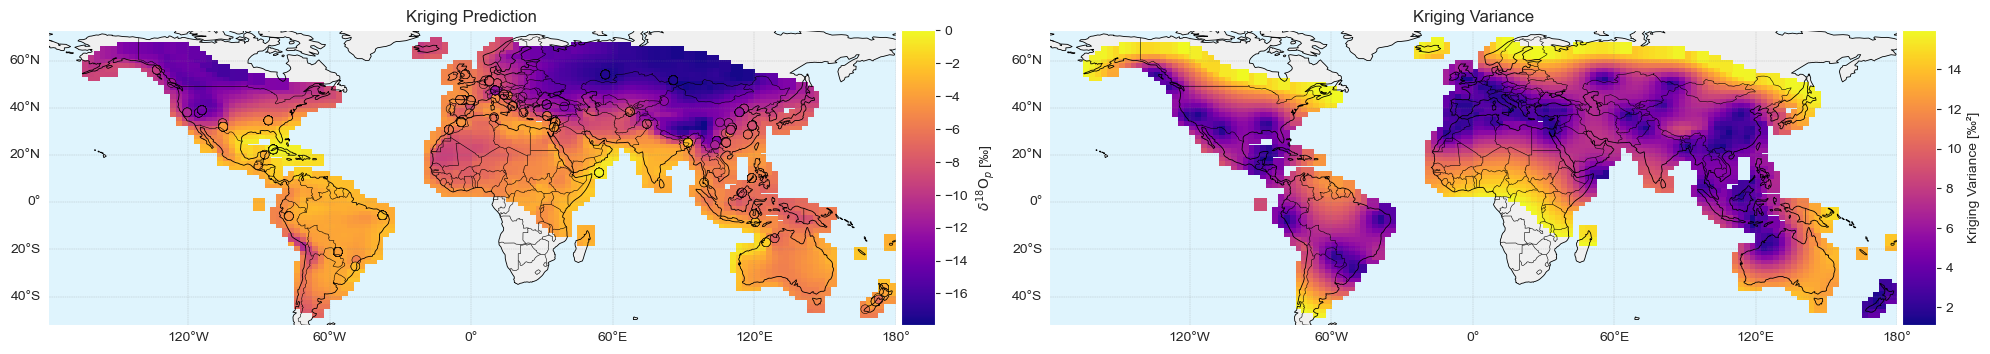

In [4]:
###### SETUP ######
qty='d18Op_VSMOW_linearized'
res_months=200*12
# vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json'
vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag8500000nlags15/trend_multiple_linear_latabs_latReLU_ele_D/no_mask/variogram_params_None.json'
temperature_ds_name = 'itrace' # 1) 'itrace' for 20-11 ka BP, or 2) 'krapp' for 0-800ka BP with res 1000 years
temperature_ds_path = '/media/luluxette/T7_Shield/pdm/iTrace/'

itrace_folder = '/media/luluxette/T7_Shield/pdm/iTrace/' # abs path to itrace data 

###### LOAD DATA ######
# SISAL 
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(
    res=res_months//12,
    temp_ds_name=temperature_ds_name,
    temp_ds_path=temperature_ds_path,
    conversion=qty
)

# ITRACE 
itrace_data = geostat_utils.get_preprocessed_itrace_data(data_folder=itrace_folder,res=res_months) # simulation 12k
itrace_times = itrace_data['time'].unique() #type:ignore # thisis the bumber of time steps in itrace df
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore
external_drift_df['lon']=utils.convert_lon_0_360_to_neg180_180(np.asarray(external_drift_df['lon'].values))
# plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
# plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore
###### VARIOGRAM ######
with open(vario_path, 'r') as f:
    variogram_dict = json.load(f)
# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}
###### EXT DRIFT AT OBS POINTS ######
# Retrieve itrace **at** observation points
lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']
# Build tree from the grid coordinates
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
tree = cKDTree(grid_points)
# Query nearest grid point for each observation
dists, idxs = tree.query(np.column_stack((lats_obs, lons_obs)))
itrace_at_obs_nn = external_drift_df['d18Op'].values[idxs]
# fig,ax = plot_utils.plot_platecarree_field_and_scatter_on_top(external_drift_df,
#                                                               pd.DataFrame({'lat':lats_obs,'lon':lons_obs,'d18Op':itrace_at_obs_nn}),
#                                                               )
# plt.show()
###### PROJECT IN MERCATOR COORDS ######
# Project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values
###### KRIGING ######
# universal kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs_nn]
)
# execute 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)
# gather results in df
df_pred = pd.DataFrame({'lon': external_drift_df['lon'],
            'lat':external_drift_df['lat'],
            'z_pred':z_pred,
            'ss_pred':ss_pred})
# mask predictions according to a kriging variance threshold
df_pred_masked = df_pred[df_pred['ss_pred']<16]
###### PLOTTING ######
fig,axes = plot_utils.plot_ked_platecarree_points(
    df_pred=df_pred_masked,
    df_obs=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,4),
    adjust_extent=False
) # type:ignore
plt.tight_layout()
# plt.savefig('../output/ked_firsttests/test_fig.png',dpi=500)
plt.show()

In [13]:
min(ss_pred)

np.float64(1.1024179343649456)

### Kriging validation metrics analysis 

In [34]:
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
res_months = 12*200
list_crossval_df = []
list_crossval_metrics = [] 
for kyr in sims.keys() :
    for time in range((int(kyr)-1)*1000+res_months//12,int(kyr)*1000+1,res_months//12):
        fp_output = f"{utils.get_project_root()}/output/kriging/run_2026_02_11_Titrace/res{res_months}/plots_and_metrics/{str(int(time))}yrBP/"
        crossval_df = pd.read_csv(f'{fp_output}crossval_df.csv').reset_index(drop=True)
        crossval_df['time']=time
        with open(fp_output+'crossval_metrics.json', 'r') as f: 
            crossval_metrics = json.load(f)
        list_crossval_df.append(crossval_df)
        list_crossval_metrics.append(pd.DataFrame(crossval_metrics,index=[time]))

crossval_df = pd.concat(list_crossval_df)
crossval_metrics = pd.concat(list_crossval_metrics)

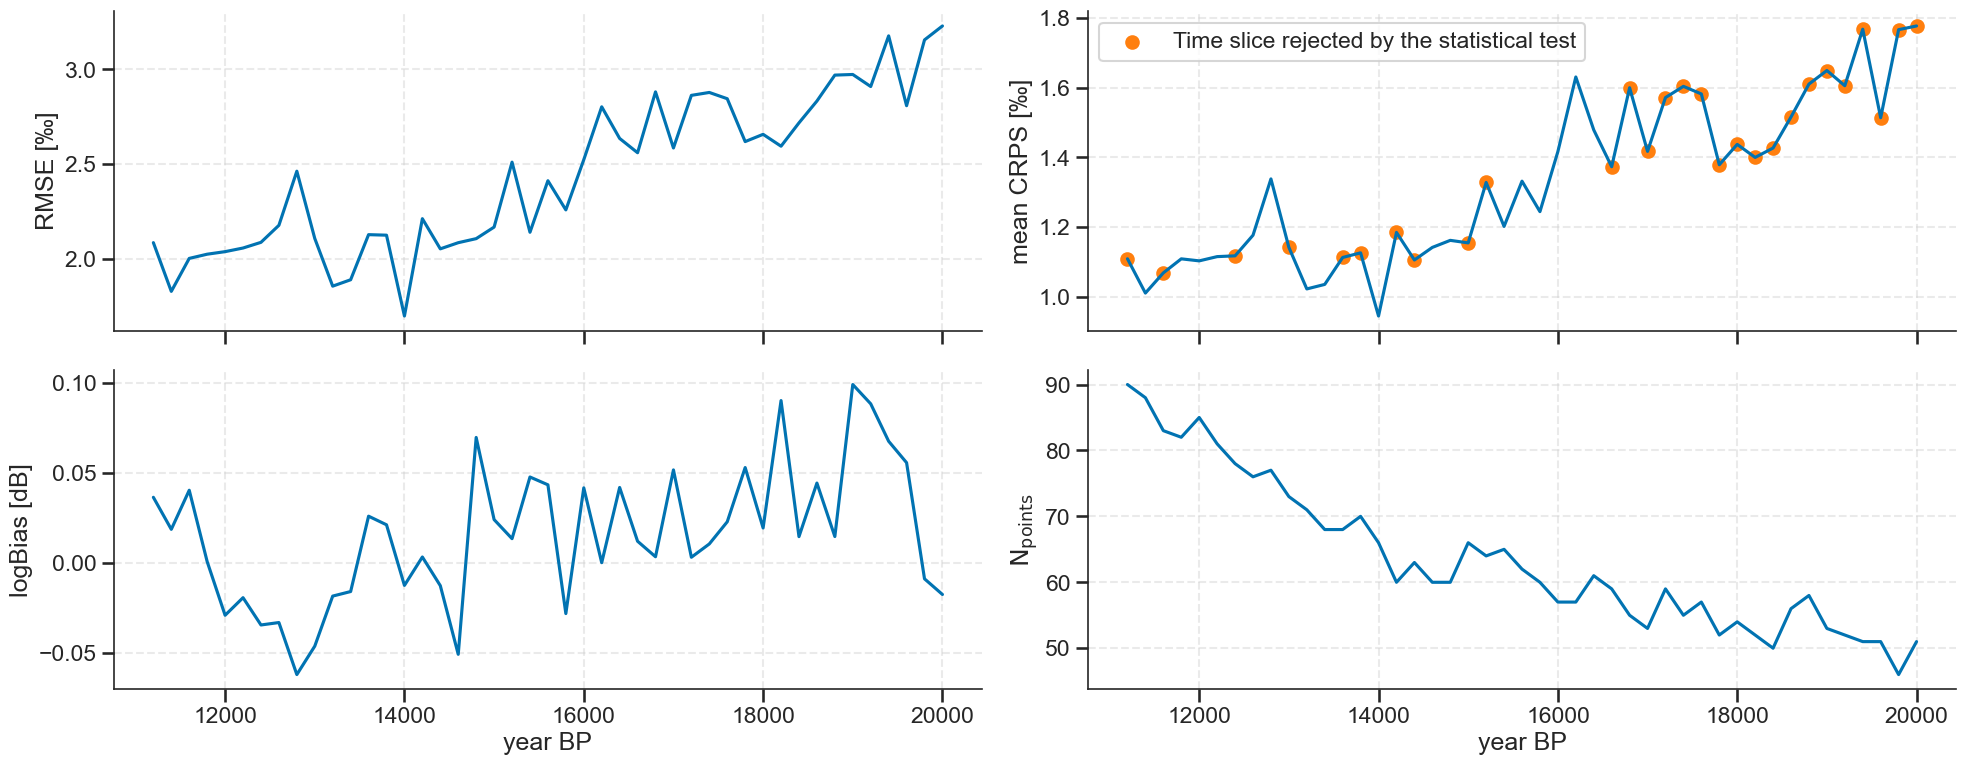

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

fig, axes = plt.subplots(2,2,figsize=(20,8),sharex=True)

# Scatter plot of irregular points
# axes[0].plot(crossval_metrics.index.values,crossval_metrics['MAE'])
axes[0,0].plot(crossval_metrics.index.values,crossval_metrics['RMSE'])
axes[0,0].set_ylabel('RMSE [‰]')
axes[1,0].plot(crossval_metrics.index.values,crossval_metrics['logbias'])
axes[1,0].set_ylabel('logBias [dB]')
axes[0,1].plot(crossval_metrics.index.values,crossval_metrics['mean CRPS'])
axes[0,1].set_ylabel('mean CRPS [‰]')
rejected_slices = crossval_df.loc[crossval_df['|PES| > critical_val'],'time'].unique()
axes[0,1].scatter(crossval_metrics[crossval_metrics.index.isin(rejected_slices)].index.values,crossval_metrics.loc[crossval_metrics.index.isin(rejected_slices),'mean CRPS'], color='tab:orange',label='Time slice rejected by the statistical test')
axes[0,1].legend()
axes[1,1].plot(crossval_metrics.index.values,np.array([len(crossval_df[crossval_df.time==t]) for t in crossval_metrics.index.values]))
axes[1,1].set_ylabel(r'$\text{N}_\text{points}$')
axes[1,1].set_xlabel('year BP')
axes[1,0].set_xlabel('year BP')
axes[0,0].grid(alpha=0.4)
axes[1,0].grid(alpha=0.4)
axes[0,1].grid(alpha=0.4)
axes[1,1].grid(alpha=0.4)
sns.despine(top=True,right=True)
plt.tight_layout()
plt.show()

In [17]:
crossval_metrics

,RMSE,MAE,mean_bias,logbias,R_obs_pred,R_pred_res,mean CRPS,Kleijnen_null_hypothesis_0.05level
11200,2.085717,1.528799,-0.063379,0.036273,0.827798,-0.044969,1.109545,rejected
11400,1.828516,1.420976,-0.031367,0.018479,0.846701,-0.019252,1.011306,not rejected
11600,2.002577,1.498733,-0.067461,0.040190,0.823199,0.005021,1.069176,rejected
11800,2.024718,1.527935,-0.000960,0.000562,0.788416,-0.088566,1.109370,not rejected
12000,2.038200,1.486573,0.051784,-0.029232,0.794289,-0.080061,1.103570,not rejected
12200,2.057334,1.482600,0.034288,-0.019465,0.779485,-0.119723,1.115740,not rejected
12400,2.087284,1.460361,0.061259,-0.034624,0.802199,-0.076167,1.117987,rejected
12600,2.177186,1.618020,0.058555,-0.033272,0.745265,-0.152906,1.177052,not rejected
12800,2.462695,1.805092,0.110143,-0.062171,0.770029,-0.155525,1.338341,not rejected
13000,2.107803,1.533980,0.080245,-0.046376,0.808275,-0.056985,1.142336,rejected


In [38]:
crossval_df.loc[crossval_df['|PES| > critical_val'],['site_name','dist_nn','PES','time']]

,site_name,dist_nn,PES,time
14,Devils Hole,174.634382,-3.660412,11200
15,Devils Hole,174.634382,-3.753156,11600
13,Devils Hole,174.634382,-3.881227,12400
14,Devils Hole,174.634382,-3.447878,13000
13,Devils Hole,408.576801,-3.782853,13600
14,Devils Hole,408.576801,-4.009770,13800
11,Devils Hole,408.576801,-3.820215,14200
13,Devils Hole,408.576801,-3.875523,14400
1,Ball Gown cave,431.804831,3.372485,15000
12,Devils Hole,340.261515,-3.788270,15000


In [43]:
crossval_df[crossval_df.site_name.isin([
    # 'Cueva del Diamante',
    # 'Cueva del Tigre Perdido',
    # 'El Condor cave',
    'Pacupahuain cave'])]

,Unnamed: 0,site_name,lon,lat,z_pred,ss_pred,z_obs,dist_nn,residual,PES,|PES| > critical_val,ci,time
38,38,Pacupahuain cave,-75.82,-11.24,-8.461445,6.138521,-15.181959,612.441323,-6.720515,-2.712506,False,8.243515,16200
41,41,Pacupahuain cave,-75.82,-11.24,-8.738304,5.890309,-15.664184,612.441323,-6.925880,-2.853684,False,8.120885,16400
41,41,Pacupahuain cave,-75.82,-11.24,-8.456846,5.899739,-16.573182,612.441323,-8.116337,-3.341517,True,8.104905,16600
39,39,Pacupahuain cave,-75.82,-11.24,-8.240299,6.302113,-17.027525,639.914760,-8.787226,-3.500328,True,8.327621,16800
37,37,Pacupahuain cave,-75.82,-11.24,-8.608282,5.918850,-17.204208,612.441323,-8.595926,-3.533247,True,8.045217,17000
42,42,Pacupahuain cave,-75.82,-11.24,-8.709065,5.879385,-17.282205,612.441323,-8.573140,-3.535688,True,8.090912,17200
36,36,Pacupahuain cave,-75.82,-11.24,-8.557875,5.871750,-17.830014,612.441323,-9.272138,-3.826451,True,8.038253,17400
40,40,Pacupahuain cave,-75.82,-11.24,-8.831367,5.845166,-17.477497,612.441323,-8.646130,-3.576213,True,8.044129,17600
33,33,Pacupahuain cave,-75.82,-11.24,-9.098195,5.866852,-17.829994,612.441323,-8.731799,-3.604966,True,7.996866,17800
35,35,Pacupahuain cave,-75.82,-11.24,-9.027127,5.842208,-17.969966,612.441323,-8.942839,-3.699874,True,8.005607,18000


In [19]:
crossval_df_nn100 = crossval_df[crossval_df.dist_nn<100]
crossval_df_nn200 = crossval_df[crossval_df.dist_nn<200]
crossval_df_nn300 = crossval_df[crossval_df.dist_nn<300]
crossval_df_nn500 = crossval_df[crossval_df.dist_nn<500]


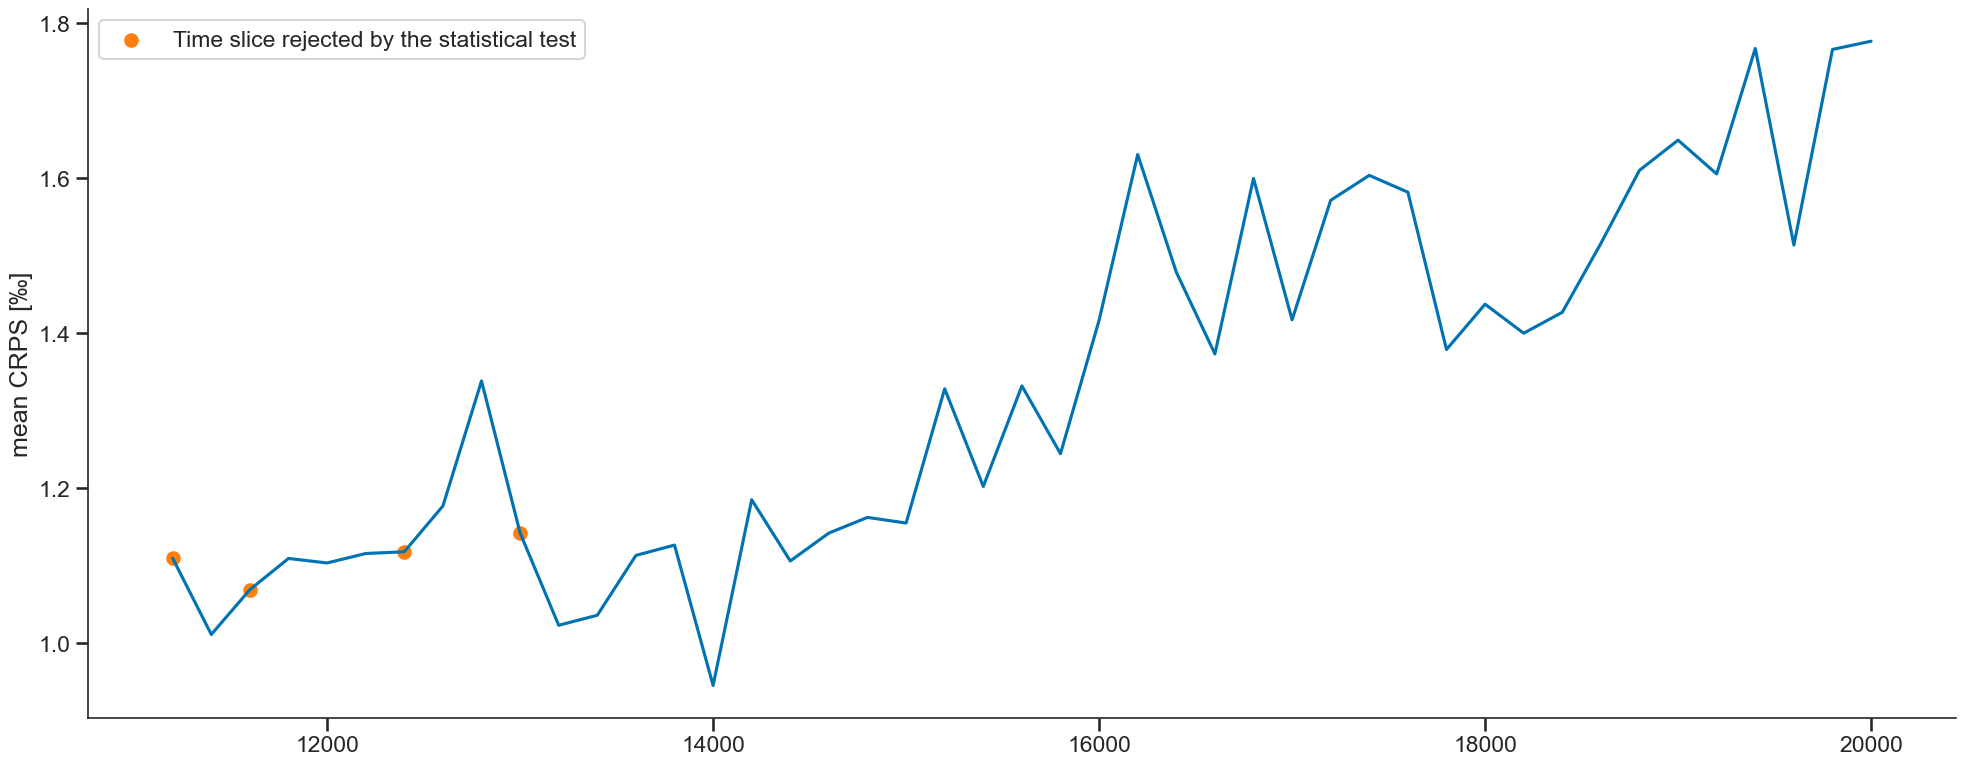

In [30]:
fig, axes = plt.subplots(1,1,figsize=(20,8),sharex=True)

axes.plot(crossval_metrics.index.values,crossval_metrics['mean CRPS'])
axes.set_ylabel('mean CRPS [‰]')
rejected_slices = crossval_df_nn200.loc[crossval_df_nn200['|PES| > critical_val'],'time'].unique()
axes.scatter(crossval_metrics[crossval_metrics.index.isin(rejected_slices)].index.values,crossval_metrics.loc[crossval_metrics.index.isin(rejected_slices),'mean CRPS'], color='tab:orange',label='Time slice rejected by the statistical test')
axes.legend()
sns.despine(top=True,right=True)
plt.tight_layout()
plt.show()